## Ridge Regularization
* Used to solve overfitting
* Types:
* * Ridge (L2)
  * Lasso (L1)
  * ElasticNet
* Loss Function : L = SUM((yi - yi_hat)^2) + {lambda*m^2}-> regularization term


## for line perfectly passing through points (1, 2.3) and (3, 5.3) : taking lambda = 1
* y = 1.5*X + 0.8 => 0 + (0.5)^2 = 2.25 -> Loss of Ln
* y = 0.9*X + 1.5 => (2.3 - 0.9 - 1.5)^2 + (5.3 - 2.7 - 1.5)^2 + (0.9)^2 = 2.03 -> loss of Lr

### for higher dimension curves : regularization term : lambda * (m1^2 + m2^2 + m3^2 + ...) called as L2 norm

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import load_diabetes

data = load_diabetes()

In [3]:
print(data.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

  :Number of Instances: 442

  :Number of Attributes: First 10 columns are numeric predictive values

  :Target: Column 11 is a quantitative measure of disease progression one year after baseline

  :Attribute Information:
      - age     age in years
      - sex
      - bmi     body mass index
      - bp      average blood pressure
      - s1      tc, total serum cholesterol
      - s2      ldl, low-density lipoproteins
      - s3      hdl, high-density lipoproteins
      - s4      tch, total cholesterol / HDL
      - s5      ltg, possibly log of serum triglycerides level
      - s6      glu, blood sugar level

Note: Each of these 1

In [4]:
X = data.data
y = data.target

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [7]:
lr.fit(X_train , y_train)

LinearRegression()

In [8]:
y_pred = lr.predict(X_test)

In [9]:
from sklearn.metrics import r2_score, mean_squared_error
print("R2", r2_score(y_test, y_pred))
print("RMSE", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 0.4526027629719195
RMSE 53.85344583676593


## Ridge Regression

In [10]:
from sklearn.linear_model import Ridge
R = Ridge(alpha=0.0001)

In [11]:
R.fit(X_train, y_train)

Ridge(alpha=0.0001)

In [12]:
y_pred1 = R.predict(X_test)

In [13]:
print("R2 : ", r2_score(y_test, y_pred))
print("RMSE : ", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 :  0.4526027629719195
RMSE :  53.85344583676593


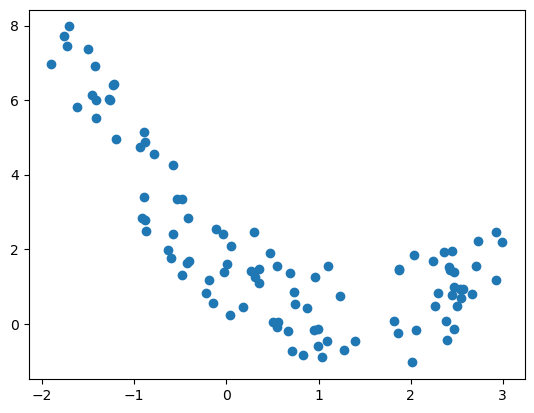

In [14]:
m = 100
x1 = 5 * np.random.rand(m, 1) - 2
x2 = 0.7*x1**2 - 2*x1 + 3*np.random.rand(m, 1)

plt.scatter(x1, x2)
plt.show()

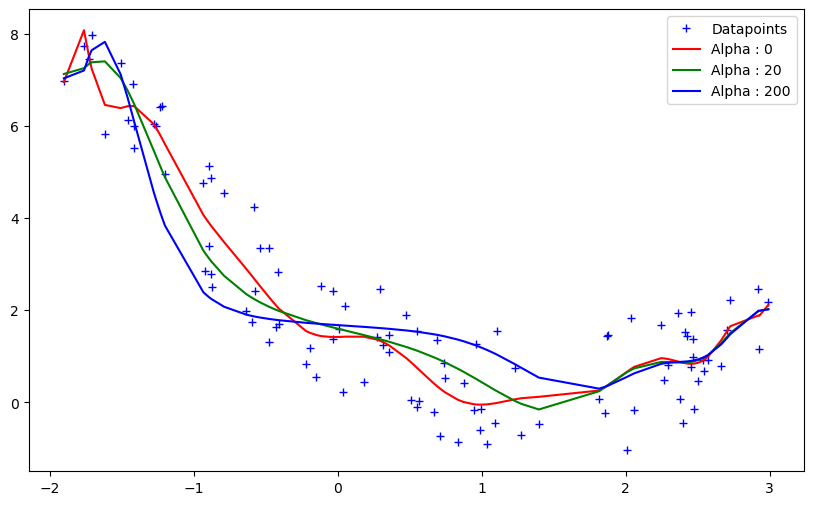

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

def get_pred_ridge(x1, x2, alpha):
    model = Pipeline([
        ('poly_feats', PolynomialFeatures(degree=16)),
        ('ridge', Ridge(alpha=alpha))
    ])

    model.fit(x1, x2)
    return model.predict(x1)

alphas = [0, 20, 200]

cs = ['r', 'g', 'b']

plt.figure(figsize=(10, 6))
plt.plot(x1, x2, 'b+', label='Datapoints')

for alpha, c in zip(alphas, cs):
    preds = get_pred_ridge(x1, x2, alpha)
    plt.plot(sorted(x1[:, 0]), preds[np.argsort(x1[:,0])], c, label = 'Alpha : {}'.format(alpha))

plt.legend()
plt.show()

* * high slope -> overfitting
* * low slope -> underfitting

## 5 Key Understandings

### 1. How coef_ gets affected?
### They shrink towards 0 but not exact zero as alpha increases

In [16]:

from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

coef = []
r2_scores = []

for i in [0, 10, 100, 1000]:
    reg = Ridge(alpha=i)
    reg.fit(X_train, y_train)

    coef.append(reg.coef_.tolist())
    y_pred = reg.predict(X_test)
    r2_scores.append(r2_score(y_test, y_pred))

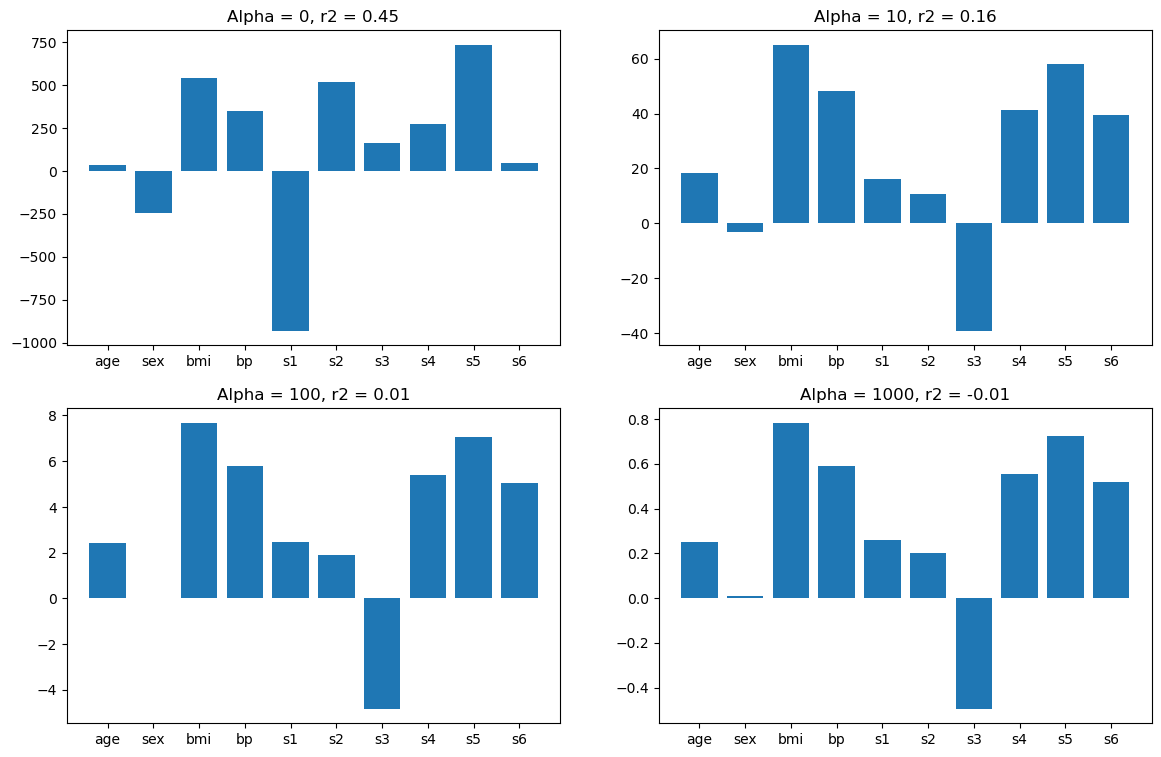

In [17]:
plt.figure(figsize=(14, 9))
plt.subplot(221)
plt.bar(data.feature_names, coef[0])
plt.title('Alpha = 0, r2 = {}'.format(round(r2_scores[0], 2)))

plt.subplot(222)
plt.bar(data.feature_names, coef[1])
plt.title('Alpha = 10, r2 = {}'.format(round(r2_scores[1], 2)))

plt.subplot(223)
plt.bar(data.feature_names, coef[2])
plt.title('Alpha = 100, r2 = {}'.format(round(r2_scores[2], 2)))

plt.subplot(224)
plt.bar(data.feature_names, coef[3])
plt.title('Alpha = 1000, r2 = {}'.format(round(r2_scores[3], 2)))

plt.show()

### 2. Higher values impacted more.

In [18]:
alphas = [0, 0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]

coef = []

for i in alphas:
    reg = Ridge(alpha=i)
    reg.fit(X_train, y_train)

    coef.append(reg.coef_.tolist())

In [19]:
input_arr = np.array(coef)

In [20]:
coef_df = pd.DataFrame(input_arr, columns=data.feature_names)
coef_df['alpha'] = alpha
coef_df.set_index('alpha')

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
alpha,,,,,,,,,,
200,37.904021,-241.964362,542.428759,347.703844,-931.488846,518.062277,163.419983,275.317902,736.198859,48.670657
200,37.968967,-241.900460,542.593504,347.604088,-919.863924,508.995920,158.213776,273.689919,731.714305,48.786920
200,38.483505,-241.351795,543.835179,346.782831,-827.701995,437.173749,116.949753,260.759264,696.129223,49.743447
200,40.693422,-237.008020,546.161792,341.809317,-430.146300,129.902301,-60.460817,203.990842,541.098025,55.482553
200,42.855670,-205.494319,505.089033,317.093205,-108.500262,-86.236733,-190.363180,151.707086,392.289319,79.908177
200,45.367377,-76.666086,291.338832,198.995817,-0.530310,-28.577050,-144.511905,119.260066,230.221608,112.149830
200,18.229623,-3.277536,65.128417,48.219668,16.238315,10.861055,-39.208913,41.438568,57.950124,39.359401
200,2.414573,0.036315,7.689592,5.786517,2.488549,1.902019,-4.832511,5.397252,7.072654,5.030673
200,0.249289,0.008728,0.783880,0.590946,0.260657,0.201464,-0.495031,0.556314,0.723795,0.517311


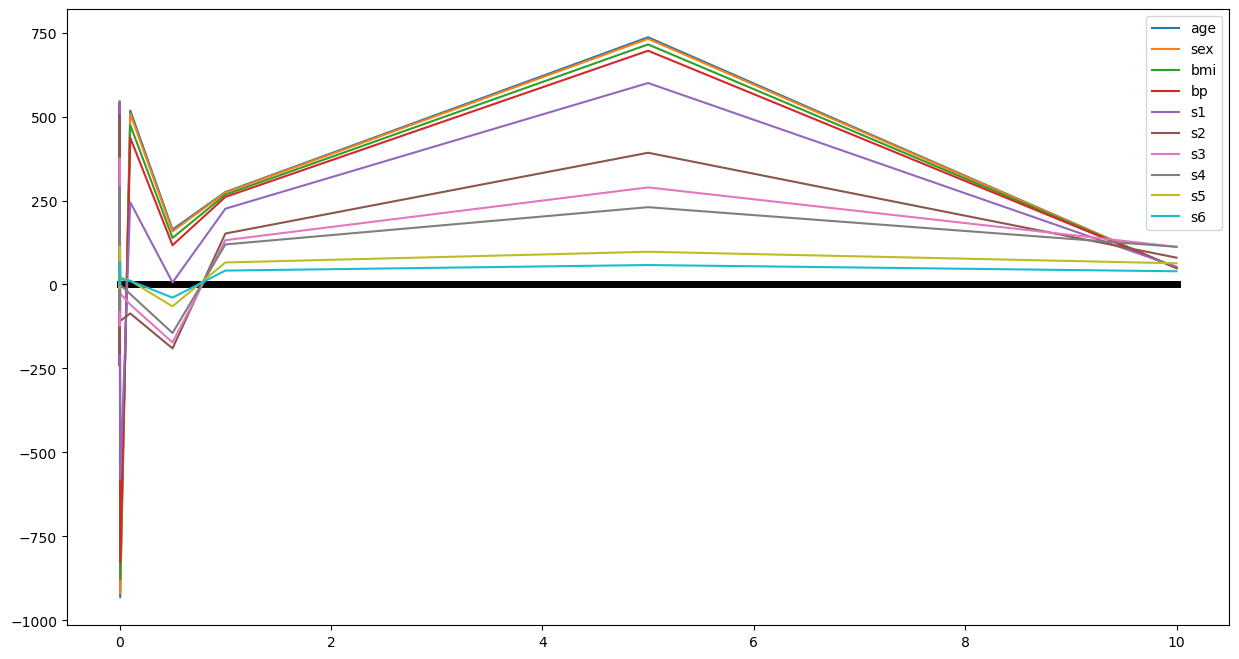

In [21]:
alphas = [0, 0.0001, 0.0005, 0.001, 0.005, 0.1, 0.5, 1, 5, 10]

coef = []

for i in alphas:
    reg = Ridge(alpha=i)
    reg.fit(X_train, y_train)

    coef.append(reg.coef_.tolist())

input_arr = np.array(coef)

plt.figure(figsize=(15,8))
plt.plot(alphas, np.zeros(len(alphas)), color='black', linewidth=5)
for i in range(input_arr.shape[0]):
    plt.plot(alphas, input_arr[i], label=data.feature_names[i])
plt.legend()

### 3. Bias Variance Tradeoff

In [22]:
# 1. Lambda inc. -> Bias dec. and Var inc. -> Overfit
# 2. Lambda dec. -> Bias inc. and Var dec. -> Underfit

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=15)

X_train = poly.fit_transform(X_train)
X_test = poly.fit_transform(X_test)

In [27]:
!pip install mlxtend

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
  Obtaining dependency information for mlxtend from https://files.pythonhosted.org/packages/a9/f9/f62b6c3bd08e1269d9bca9aabe0d990a7c3ffbfbcc495135ad0b59ce860b/mlxtend-0.24.0-py3-none-any.whl.metadata
  Obtaining dependency information for scipy>=1.16.3 from https://files.pythonhosted.org/packages/09/7d/af933f0f6e0767995b4e2d705a0665e454d1c19402aa7e895de3951ebb04/scipy-1.17.1-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 1.9 MB/s eta 0:00:00
  Obtaining dependency information for numpy>=2.3.5 from https://files.pythonhosted.org/packages/1b/46/6fa4ea94f1ddf969b2ee941290cca6f1bfac92b53c76ae5f44afe17ceb69/numpy-2.4.2-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata
  Obtaining dependency information for pandas>=2.3.3 from https://files.pythonhosted.org/packages/2e/7c/870c7e

In [28]:
from mlxtend.evaluate import bias_variance_decomp

alphas = np.linspace(0, 30, 100)

loss = []
bias = []
var = []

for i in alphas:
    reg = Ridge(alpha = i)
    avg_expected_loss, avg_bias, avg_var = bias_variance_decomp(
        reg, X_train, y_train, X_test, y_test,
        loss='mse',
        random_seed=123
    )
    loss.append(avg_expected_loss)
    bias.append(avg_bias)
    var.append(avg_var)

ImportError: cannot import name 'get_tags' from 'sklearn.utils._tags' (/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/sklearn/utils/_tags.py)

### 4. Impact on the loss function

[27.88303667]
-2.8684306983462244


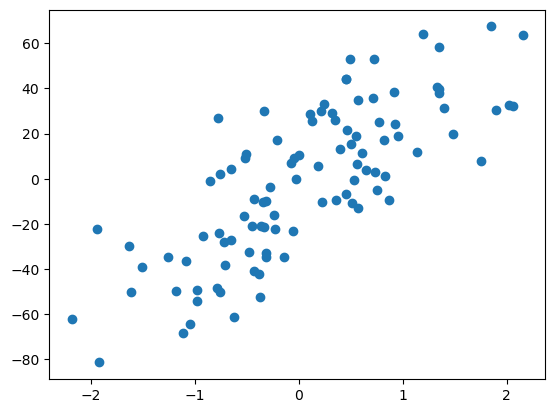

In [30]:
from sklearn.datasets import make_regression

X, y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1, noise=25, random_state=13)

plt.scatter(X, y)

from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit(X, y)
print(reg.coef_)
print(reg.intercept_)

In [31]:
def cal_loss(m, alpha):
    return np.sum((y-m*X.ravel() + 2.29)**2) + alpha*m*m

In [32]:
def predict(m):
    return m*X - 2.29

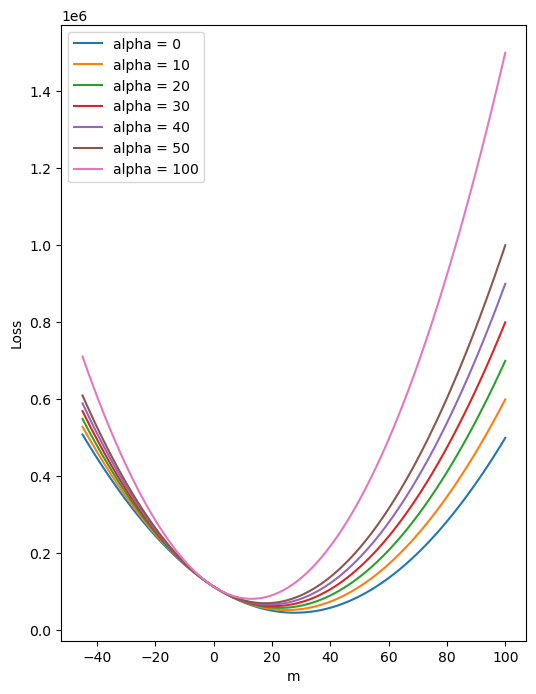

In [35]:
m = np.linspace(-45, 100, 100)
plt.figure(figsize=(6, 8))
for j in [0, 10, 20, 30, 40, 50, 100]:
    loss = []
    for i in range(m.shape[0]):
        loss_i = cal_loss(m[i], j)
        loss.append(loss_i)
    plt.plot(m, loss, label='alpha = {}'.format(j))
plt.legend()
plt.xlabel('m')
plt.ylabel('Loss')
plt.show()

### Why called Ridge?

### Use Ridge reg when input vars > 2